In [43]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from fismi import ismiReplication as fismi
from fismi import figures

In [44]:
# Import data
niv = '3'

# HICP All Items
colHicp = "INX"

# Unchained other items 
# dfICP = pd.read_parquet(f"input/EAunchainedItemsLvl{niv}.parquet")
# dfW = pd.read_parquet(f"input/EAnormedWeightsLvl{niv}.parquet") 
dfICP = pd.read_parquet(f"input/EArawItemsLvl{niv}.parquet")
dfW = pd.read_parquet(f"input/EArawWeightsLvl{niv}.parquet") 

In [45]:
# We compute headline inflation (HICP variation over a 12-month period)
headline = np.log(dfICP["INX"]).diff(12)[1:]*100  # Inflation headline annuelle glissante

# We compute monthly inflation rates on Unchained items
dfInflation = np.log(dfICP).diff(1)[1:]*100
InflTot = dfInflation["INX"].to_frame()         # To replicate Figure A1
dfInflation = dfInflation.drop("INX",axis=1)

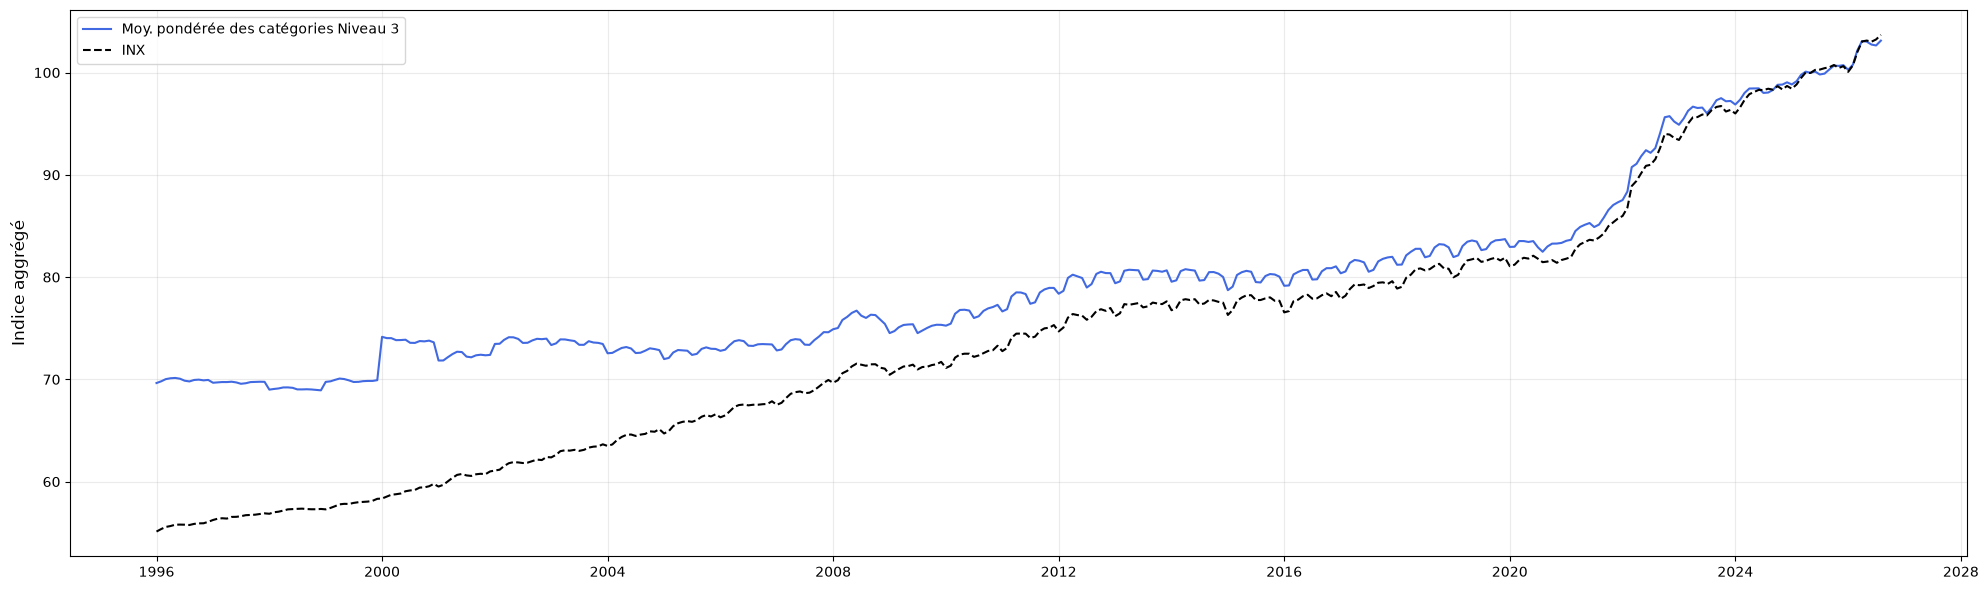

In [46]:
# Graphique 1
figures.plotAggregatedIndex(dfW,dfICP,"INX",niv)

In [37]:
# Call functions
df_shocks, aCoef, rhoCoef = fismi.twoStepsAr(dfInflation, rolling_window=120)
posItems, negItems, posIsmi, negIsmi, ismIndex = fismi.replicateIsmi(dfInflation, df_shocks, dfW)

Step 1 : Estimate 126 AR(1) on a 120 month rolling window...
Step 2 : Compute inflation momentum and aggregate...
Done


In [38]:
# Merge
ismIndex = ismIndex.to_frame().merge(
    InflTot,
    how="left",
    left_index=True,
    right_index=True)

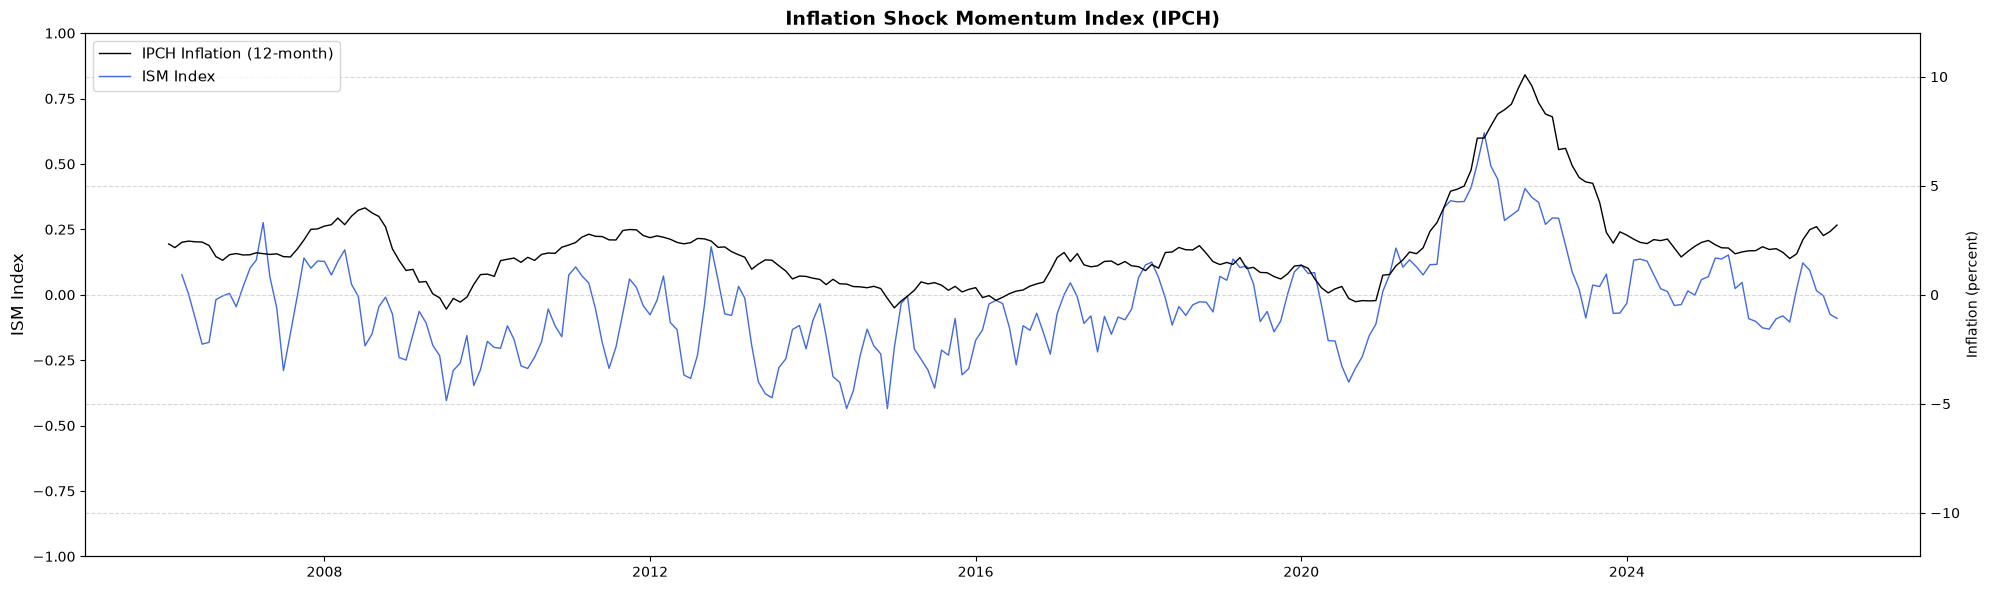

In [47]:
# Figure 2
figures.ismiVersusIndex(ismIndex, headline[120:], index="IPCH")

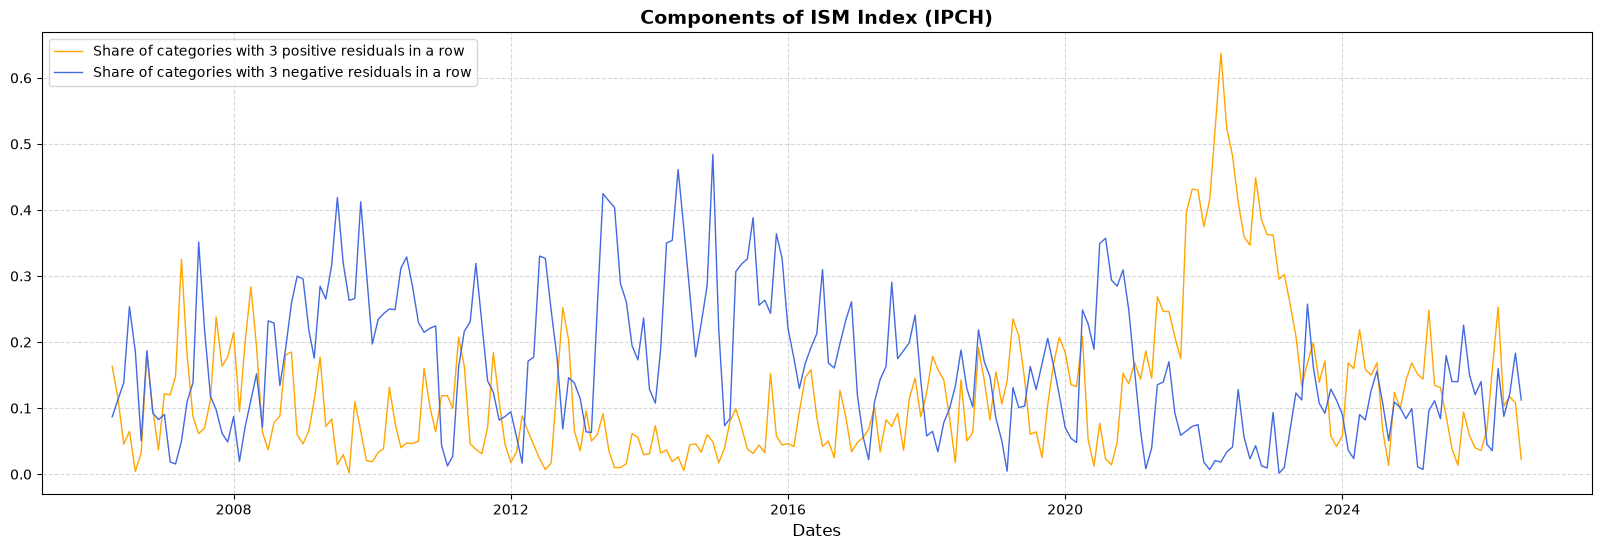

In [48]:
# Figure 3 
figures.posVersusNeg(posIsmi,negIsmi,index="IPCH")

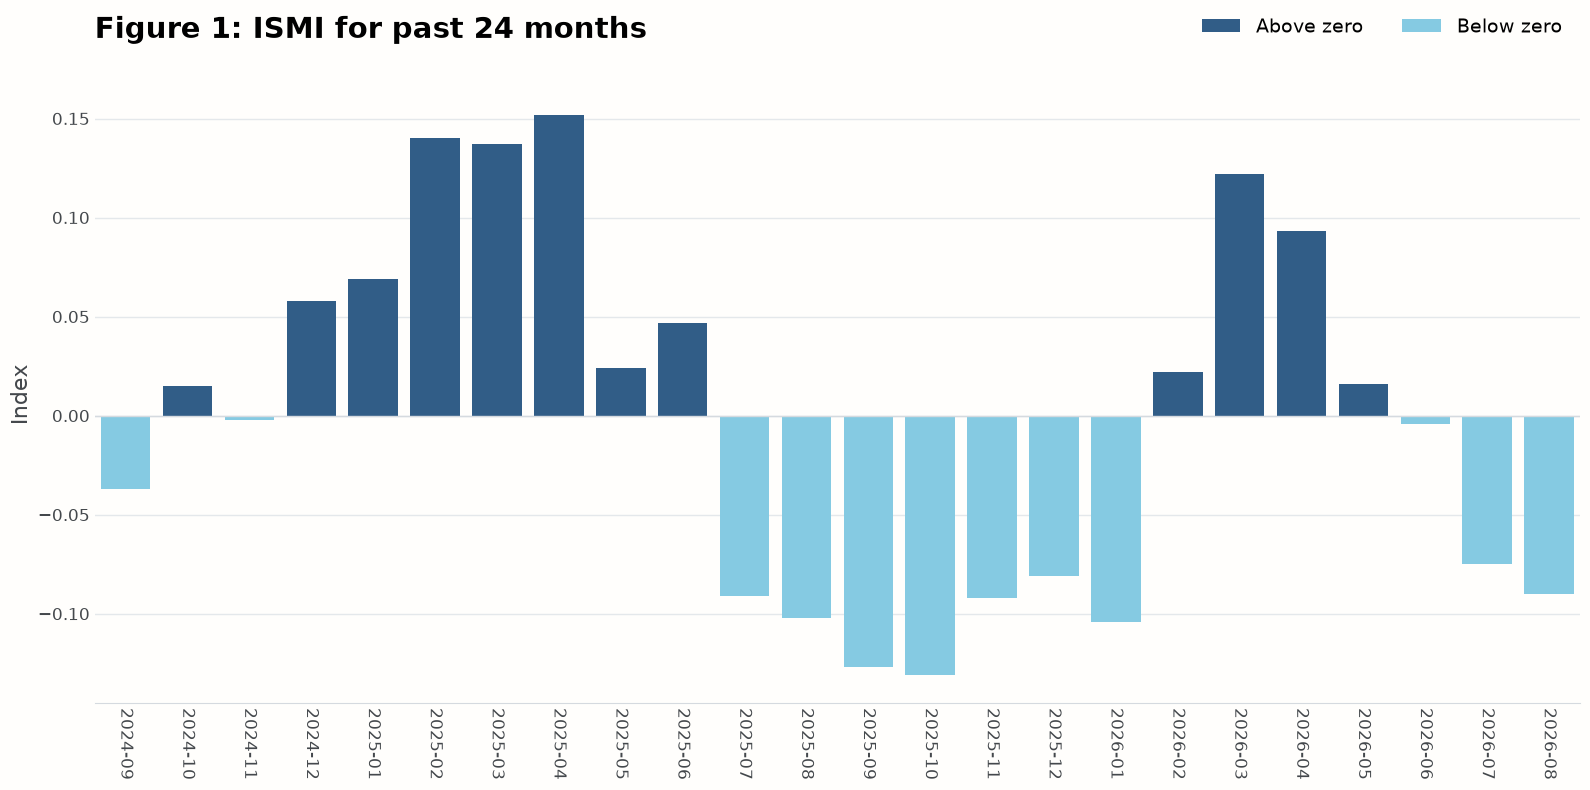

In [49]:
# Fed Chart Type
figures.FedStyleChart(ismIndex)

In [41]:
# Réplication Figure A1
df_shocks, aCoef, rhoCoef = fismi.twoStepsAr(InflTot)

# Drop NaN and merge
HICP = InflTot.copy()
HICP["Shocks"] = df_shocks.values
HICP["A"] = aCoef.values
HICP["Rho"] = rhoCoef.values
HICP = HICP.dropna()

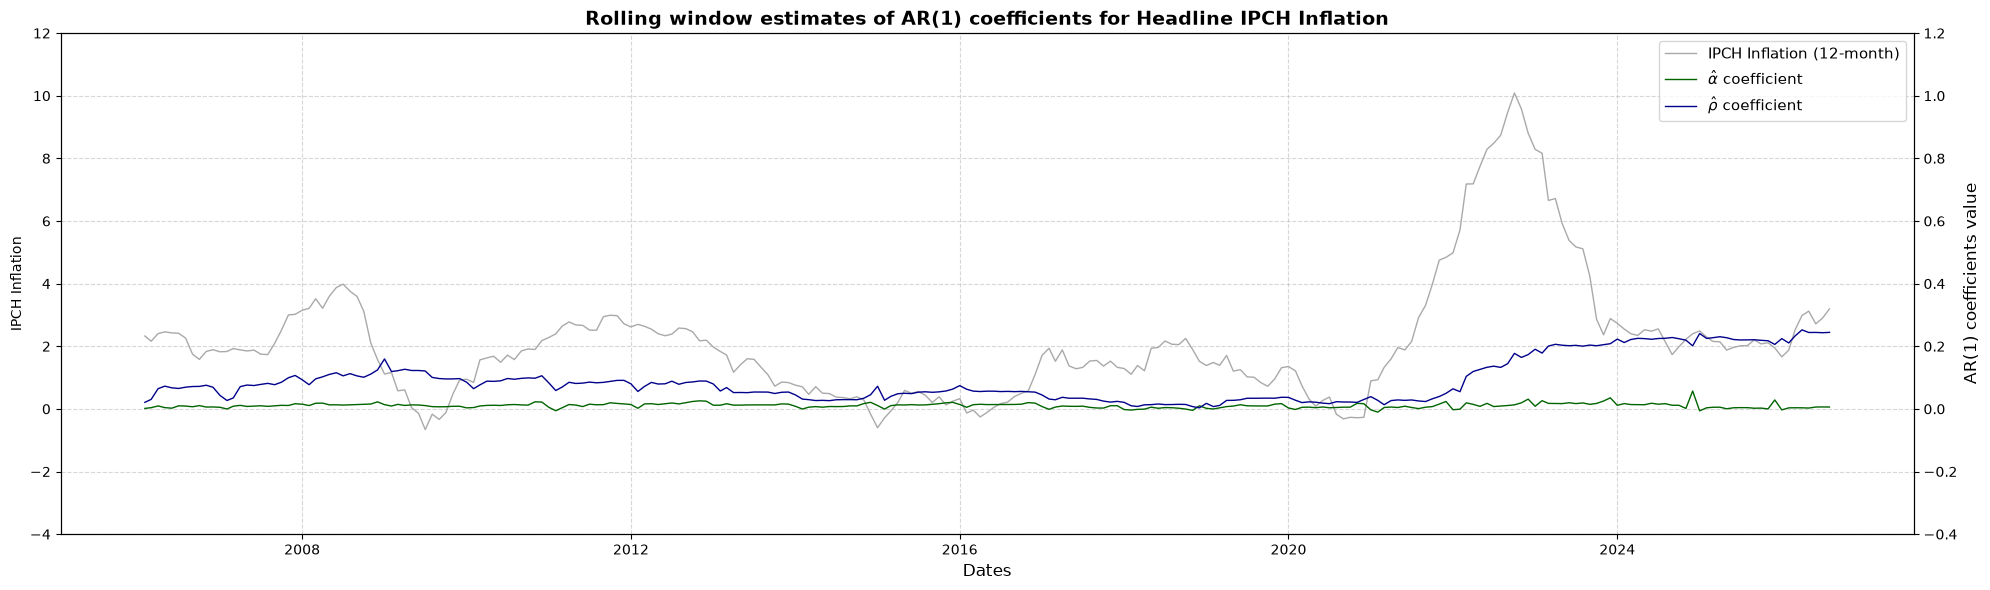

In [50]:
# Appendix A1
figures.figA1Paper(headline.iloc[120:], HICP,"IPCH")

When $\alpha = 0$ the shocks tend to die out immediately. If positive, they are self reinforcing.